
Best parameters found by GridSearchCV:
{'reg_alpha': 0.1, 'colsample_bytree': 1.0, 'subsample': 1.0, 'subsample_freq': 0, 'linear_tree': True, 'learning_rate': 0.12, 'max_depth': 2, 'min_child_samples': 15, 'n_estimators': 80, 'num_leaves': 3, 'reg_lambda': 3.0}


5-Fold CV Evaluation Progress: 5it [00:00, 29.90it/s]


Cross-Validation Results for Each Fold (anti-overfit tuned):

Fold 1:  MSE 1.2698 | RMSE 1.1269 | MAE 0.8992 | MRE 11.76% | R2 0.8798

Fold 2:  MSE 0.6021 | RMSE 0.7760 | MAE 0.6041 | MRE 5.55% | R2 0.8723

Fold 3:  MSE 0.6946 | RMSE 0.8334 | MAE 0.6996 | MRE 5.81% | R2 0.8007

Fold 4:  MSE 2.0932 | RMSE 1.4468 | MAE 0.9550 | MRE 17.31% | R2 0.7607

Fold 5:  MSE 2.3670 | RMSE 1.5385 | MAE 1.2485 | MRE 12.40% | R2 0.7713


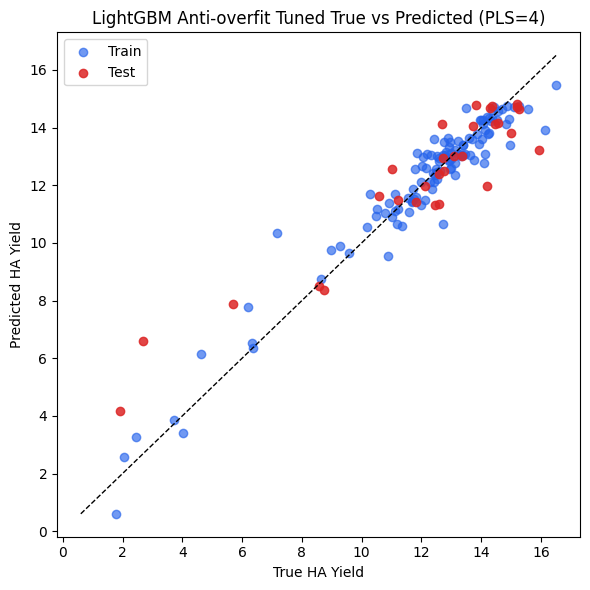

LightGBM Tuned Best Parameters:
{'reg_alpha': 0.1, 'colsample_bytree': 1.0, 'subsample': 1.0, 'subsample_freq': 0, 'linear_tree': True, 'learning_rate': 0.12, 'max_depth': 2, 'min_child_samples': 15, 'n_estimators': 80, 'num_leaves': 3, 'reg_lambda': 3.0}

PLS Components: 4
PLS Cumulative Variance Ratio: 97.2369%

===== Cross-Validation (5-fold Average) =====
MSE : 1.4053 ± 0.7165
RMSE: 1.1443 ± 0.3097
MAE : 0.8813 ± 0.2238
MRE : 10.57% ± 4.43%
R2  : 0.8170 ± 0.0501

===== Training Set Metrics =====
MSE: 0.4973
RMSE: 0.7052
MAE: 0.4938
MRE: 5.37%
R2: 0.9354

===== Test Set Metrics =====
MSE: 1.6725
RMSE: 1.2933
MAE: 0.9149
MRE: 14.87%
R2: 0.8567

===== Overfitting gap check (R2, threshold 0.15) =====
|CV-Train| = 0.1184
|CV-Test | = 0.0397
|Train-Test| = 0.0787
Max pairwise gap = 0.1184  ==> PASS (no overfitting)


In [5]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import GroupShuffleSplit, GroupKFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from lightgbm import LGBMRegressor
from tqdm import tqdm

warnings.filterwarnings("ignore")

base_dir = Path.cwd()
spectra_path = base_dir / "pattern.xlsx"
label_path = base_dir / "label.xlsx"
output_path = spectra_path.with_name("LightGBM.xlsx")
output_dir = spectra_path.parent / "lightgbm_pls4_tuned_visual"
output_dir.mkdir(exist_ok=True)
cv_predictions_dir = output_dir / "cv_fold_predictions"
cv_predictions_dir.mkdir(exist_ok=True)

spectra_df = pd.read_excel(spectra_path, header=None)
label_df = pd.read_excel(label_path, header=None)
id_col = "ID"
target_col = "HA Yield"
feature_cols = [f"Feature_{i}" for i in range(1, spectra_df.shape[1])]
spectra_df.columns = [id_col] + feature_cols
label_df = label_df.iloc[:, :2].copy()
label_df.columns = [id_col, target_col]

def normalize_id(x):
    if pd.isna(x):
        return np.nan
    if isinstance(x, (int, np.integer)):
        return str(x)
    if isinstance(x, (float, np.floating)):
        return str(int(x)) if x.is_integer() else str(x).rstrip("0").rstrip(".")
    return str(x).strip()

spectra_df[id_col] = spectra_df[id_col].map(normalize_id)
label_df[id_col] = label_df[id_col].map(normalize_id)
label_df[target_col] = pd.to_numeric(label_df[target_col], errors="coerce")
label_check = label_df.groupby(id_col)[target_col].nunique(dropna=False)
conflict_ids = label_check[label_check > 1].index.tolist()
if conflict_ids:
    raise ValueError(f"The following IDs have multiple different HA yields, please check label.xlsx: {conflict_ids}")
label_unique = label_df.drop_duplicates(subset=[id_col], keep="first")
df = spectra_df.merge(label_unique, on=id_col, how="left")
if df[target_col].isna().any():
    missing_ids = df.loc[df[target_col].isna(), id_col].unique()
    raise ValueError(f"The following IDs are not found in label.xlsx: {missing_ids}")

X = df[feature_cols].apply(pd.to_numeric, errors="coerce")
X = X.fillna(X.mean()).fillna(0)
y = df[target_col].astype(float)
X_standard = (X - X.mean(axis=0)) / X.std(axis=0, ddof=0).replace(0, 1)

n_components = 4
max_components = min(X_standard.shape[0] - 1, X_standard.shape[1])
if n_components > max_components:
    raise ValueError(f"At most {max_components} PLS components can be extracted, cannot set to {n_components}.")

pls = PLSRegression(n_components=n_components, scale=False)
pls.fit(X_standard.values, y.values.reshape(-1, 1))
X_scores = pls.x_scores_
X_reconstructed = X_scores @ pls.x_loadings_.T
ss_total = np.sum(X_standard.values ** 2)
ss_residual = np.sum((X_standard.values - X_reconstructed) ** 2)
cumulative_variance_ratio = 1 - ss_residual / ss_total

pls_cols = [f"PLS_Component_{i + 1}" for i in range(n_components)]
df_pls = pd.DataFrame(X_scores, columns=pls_cols)
df_pls.insert(0, id_col, df[id_col].values)
df_pls[target_col] = y.values
X_model = df_pls[pls_cols].astype(float)
y_model = df_pls[target_col].astype(float)
groups = df_pls[id_col].astype(str)

splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(splitter.split(X_model, y_model, groups=groups))
X_train = X_model.iloc[train_idx]
X_test = X_model.iloc[test_idx]
y_train = y_model.iloc[train_idx]
y_test = y_model.iloc[test_idx]
groups_train = groups.iloc[train_idx]

best_params = {
    'reg_alpha': 0.1,
    'colsample_bytree': 1.0,
    'subsample': 1.0,
    'subsample_freq': 0,
    'linear_tree': True,
    'learning_rate': 0.12,
    'max_depth': 2,
    'min_child_samples': 15,
    'n_estimators': 80,
    'num_leaves': 3,
    'reg_lambda': 3.0
}

print("\nBest parameters found by GridSearchCV:")
print(best_params)

n_splits = min(5, groups_train.nunique())
if n_splits < 2:
    raise ValueError("Not enough groups in training set for GroupKFold cross-validation.")
cv = GroupKFold(n_splits=n_splits)

cv_mse_scores, cv_rmse_scores, cv_mae_scores, cv_mre_scores, cv_r2_scores = [], [], [], [], []
cv_predictions = []

for fold_idx, (train_idx_cv, val_idx_cv) in enumerate(tqdm(cv.split(X_train, y_train, groups=groups_train), desc="5-Fold CV Evaluation Progress")):
    X_tr = X_train.iloc[train_idx_cv]
    y_tr = y_train.iloc[train_idx_cv]
    X_val = X_train.iloc[val_idx_cv]
    y_val = y_train.iloc[val_idx_cv]

    fold_model = LGBMRegressor(objective="regression", random_state=42, n_jobs=-1,
                               verbose=-1, **best_params)
    fold_model.fit(X_tr, y_tr)
    y_val_pred = fold_model.predict(X_val)

    mse_val = mean_squared_error(y_val, y_val_pred)
    rmse_val = np.sqrt(mse_val)
    mae_val = mean_absolute_error(y_val, y_val_pred)
    mre_val = np.mean(np.abs(y_val - y_val_pred) / y_val) * 100
    r2_val = r2_score(y_val, y_val_pred)

    cv_mse_scores.append(mse_val)
    cv_rmse_scores.append(rmse_val)
    cv_mae_scores.append(mae_val)
    cv_mre_scores.append(mre_val)
    cv_r2_scores.append(r2_val)

    fold_pred_df = pd.DataFrame({
        id_col: df_pls.iloc[train_idx].iloc[val_idx_cv][id_col].values,
        "Fold": f"Fold_{fold_idx + 1}",
        "True_HA_Yield": y_val.values,
        "Predicted_HA_Yield": y_val_pred,
        "Residual": y_val.values - y_val_pred,
        "Absolute_Error": np.abs(y_val.values - y_val_pred),
        "Relative_Error_%": np.abs(y_val.values - y_val_pred) / y_val.values * 100
    })
    cv_predictions.append(fold_pred_df)
    fold_output_path = cv_predictions_dir / f"fold_{fold_idx + 1}_predictions.xlsx"
    with pd.ExcelWriter(fold_output_path, engine="openpyxl") as writer:
        fold_pred_df.to_excel(writer, sheet_name="predictions", index=False)
        pd.DataFrame({"Metric": ["MSE", "RMSE", "MAE", "MRE_%", "R2"],
                      "Value": [mse_val, rmse_val, mae_val, mre_val, r2_val]}
                     ).to_excel(writer, sheet_name="metrics", index=False)
        pd.DataFrame({"Info": ["Training samples", "Validation samples", "Fold number"],
                      "Value": [len(X_tr), len(X_val), fold_idx + 1]}
                     ).to_excel(writer, sheet_name="info", index=False)

cv_mse, cv_rmse, cv_mae, cv_mre, cv_r2 = (np.mean(s) for s in
    (cv_mse_scores, cv_rmse_scores, cv_mae_scores, cv_mre_scores, cv_r2_scores))
cv_mse_std, cv_rmse_std, cv_mae_std, cv_mre_std, cv_r2_std = (np.std(s) for s in
    (cv_mse_scores, cv_rmse_scores, cv_mae_scores, cv_mre_scores, cv_r2_scores))

print("\n" + "="*60)
print("Cross-Validation Results for Each Fold (anti-overfit tuned):")
print("="*60)
for i in range(n_splits):
    print(f"\nFold {i+1}:  MSE {cv_mse_scores[i]:.4f} | RMSE {cv_rmse_scores[i]:.4f} | "
          f"MAE {cv_mae_scores[i]:.4f} | MRE {cv_mre_scores[i]:.2f}% | R2 {cv_r2_scores[i]:.4f}")

model = LGBMRegressor(objective="regression", random_state=42, n_jobs=-1, verbose=-1, **best_params)
model.fit(X_train, y_train)
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
train_rmse = np.sqrt(train_mse)
test_rmse = np.sqrt(test_mse)
train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)
train_mre = np.mean(np.abs(y_train - y_train_pred) / y_train) * 100
test_mre = np.mean(np.abs(y_test - y_test_pred) / y_test) * 100

gap_cv_tr = abs(cv_r2 - train_r2)
gap_cv_te = abs(cv_r2 - test_r2)
gap_tr_te = abs(train_r2 - test_r2)
max_r2_gap = max(gap_cv_tr, gap_cv_te, gap_tr_te)
overfit_pass = max_r2_gap < 0.15

train_result_df = pd.DataFrame({
    id_col: df_pls.iloc[train_idx][id_col].values, "Dataset": "Training",
    "True HA Yield": y_train.values, "Predicted HA Yield": y_train_pred})
test_result_df = pd.DataFrame({
    id_col: df_pls.iloc[test_idx][id_col].values, "Dataset": "Test",
    "True HA Yield": y_test.values, "Predicted HA Yield": y_test_pred})
all_result_df = pd.concat([train_result_df, test_result_df], axis=0).reset_index(drop=True)

def id_sort_key(x):
    try:
        return float(str(x).strip())
    except ValueError:
        return np.inf
all_result_df["Sort Key"] = all_result_df[id_col].map(id_sort_key)
all_result_df["Group Index"] = all_result_df.groupby(id_col).cumcount() + 1
all_result_sorted_df = all_result_df.sort_values(
    by=["Sort Key", "Group Index"], ascending=[True, True]).drop(columns=["Sort Key"])

metrics_df = pd.DataFrame({
    "Metric": ["PLS Components", "PLS Cumulative Variance Ratio",
        "CV MSE (Average)", "CV RMSE (Average)", "CV MAE (Average)", "CV MRE(%) (Average)", "CV R2 (Average)",
        "CV MSE (Std)", "CV RMSE (Std)", "CV MAE (Std)", "CV MRE(%) (Std)", "CV R2 (Std)",
        "Training MSE", "Test MSE", "Training RMSE", "Test RMSE", "Training MAE", "Test MAE",
        "Training MRE(%)", "Test MRE(%)", "Training R2", "Test R2",
        "|CV-Train R2 gap|", "|CV-Test R2 gap|", "|Train-Test R2 gap|", "Max pairwise R2 gap",
        "Overfit check (max gap < 0.15)"],
    "Value": [n_components, cumulative_variance_ratio,
        cv_mse, cv_rmse, cv_mae, cv_mre, cv_r2,
        cv_mse_std, cv_rmse_std, cv_mae_std, cv_mre_std, cv_r2_std,
        train_mse, test_mse, train_rmse, test_rmse, train_mae, test_mae,
        train_mre, test_mre, train_r2, test_r2,
        gap_cv_tr, gap_cv_te, gap_tr_te, max_r2_gap, "PASS" if overfit_pass else "FAIL"]
})
best_params_df = pd.DataFrame(list(best_params.items()), columns=["Parameter", "Best Value"])
feature_importance_df = pd.DataFrame({"Feature": pls_cols, "Importance": model.feature_importances_}
                                     ).sort_values("Importance", ascending=False)

plt.figure(figsize=(6, 6))
plt.scatter(y_train, y_train_pred, alpha=0.65, label="Train", color="#2563EB")
plt.scatter(y_test, y_test_pred, alpha=0.85, label="Test", color="#DC2626")
min_v = min(y_train.min(), y_test.min(), y_train_pred.min(), y_test_pred.min())
max_v = max(y_train.max(), y_test.max(), y_train_pred.max(), y_test_pred.max())
plt.plot([min_v, max_v], [min_v, max_v], "k--", linewidth=1)
plt.xlabel("True HA Yield")
plt.ylabel("Predicted HA Yield")
plt.title("LightGBM Anti-overfit Tuned True vs Predicted (PLS=4)")
plt.legend()
plt.tight_layout()
plt.savefig(output_dir / "true_vs_predicted_train_test.png", dpi=300)
plt.show()

with pd.ExcelWriter(output_path, engine="openpyxl") as writer:
    df_pls.to_excel(writer, sheet_name="pls_scores_4", index=False)
    train_result_df.to_excel(writer, sheet_name="train_predictions", index=False)
    test_result_df.to_excel(writer, sheet_name="test_predictions", index=False)
    all_result_sorted_df.to_excel(writer, sheet_name="all_predictions_by_id", index=False)
    metrics_df.to_excel(writer, sheet_name="metrics", index=False)
    best_params_df.to_excel(writer, sheet_name="best_params", index=False)
    feature_importance_df.to_excel(writer, sheet_name="feature_importance", index=False)
    for fold_pred_df in cv_predictions:
        fold_pred_df.to_excel(writer, sheet_name=f"{fold_pred_df['Fold'].iloc[0]}_predictions", index=False)
    pd.DataFrame({"Fold": [f"Fold_{i+1}" for i in range(n_splits)], "MSE": cv_mse_scores,
                  "RMSE": cv_rmse_scores, "MAE": cv_mae_scores, "MRE_%": cv_mre_scores,
                  "R2": cv_r2_scores}).to_excel(writer, sheet_name="cv_fold_summary", index=False)

cv_predictions_summary_path = output_dir / "all_cv_fold_predictions.xlsx"
with pd.ExcelWriter(cv_predictions_summary_path, engine="openpyxl") as writer:
    for fold_pred_df in cv_predictions:
        fold_pred_df.to_excel(writer, sheet_name=fold_pred_df["Fold"].iloc[0], index=False)
    pd.DataFrame({"Fold": [f"Fold_{i+1}" for i in range(n_splits)], "MSE": cv_mse_scores,
                  "RMSE": cv_rmse_scores, "MAE": cv_mae_scores, "MRE_%": cv_mre_scores,
                  "R2": cv_r2_scores}).to_excel(writer, sheet_name="summary", index=False)

print("="*60)
print("LightGBM Tuned Best Parameters:")
print(best_params)
print(f"\nPLS Components: {n_components}")
print(f"PLS Cumulative Variance Ratio: {cumulative_variance_ratio:.4%}")
print("\n===== Cross-Validation (5-fold Average) =====")
print(f"MSE : {cv_mse:.4f} ± {cv_mse_std:.4f}")
print(f"RMSE: {cv_rmse:.4f} ± {cv_rmse_std:.4f}")
print(f"MAE : {cv_mae:.4f} ± {cv_mae_std:.4f}")
print(f"MRE : {cv_mre:.2f}% ± {cv_mre_std:.2f}%")
print(f"R2  : {cv_r2:.4f} ± {cv_r2_std:.4f}")
print(f"\n===== Training Set Metrics =====")
print(f"MSE: {train_mse:.4f}\nRMSE: {train_rmse:.4f}\nMAE: {train_mae:.4f}\nMRE: {train_mre:.2f}%\nR2: {train_r2:.4f}")
print(f"\n===== Test Set Metrics =====")
print(f"MSE: {test_mse:.4f}\nRMSE: {test_rmse:.4f}\nMAE: {test_mae:.4f}\nMRE: {test_mre:.2f}%\nR2: {test_r2:.4f}")
print("\n===== Overfitting gap check (R2, threshold 0.15) =====")
print(f"|CV-Train| = {gap_cv_tr:.4f}")
print(f"|CV-Test | = {gap_cv_te:.4f}")
print(f"|Train-Test| = {gap_tr_te:.4f}")
print(f"Max pairwise gap = {max_r2_gap:.4f}  ==> {'PASS (no overfitting)' if overfit_pass else 'FAIL (still overfitting)'}")


Best parameters found by GridSearchCV:
{'reg_alpha': 0.1, 'colsample_bytree': 1.0, 'subsample': 1.0, 'subsample_freq': 0, 'linear_tree': True, 'learning_rate': 0.12, 'max_depth': 2, 'min_child_samples': 15, 'n_estimators': 80, 'num_leaves': 3, 'reg_lambda': 3.0}


5-Fold CV Evaluation Progress: 5it [00:00, 29.73it/s]


Cross-Validation Results for Each Fold (anti-overfit tuned):

Fold 1:  MSE 1.2698 | RMSE 1.1269 | MAE 0.8992 | MRE 11.76% | R2 0.8798

Fold 2:  MSE 0.6021 | RMSE 0.7760 | MAE 0.6041 | MRE 5.55% | R2 0.8723

Fold 3:  MSE 0.6946 | RMSE 0.8334 | MAE 0.6996 | MRE 5.81% | R2 0.8007

Fold 4:  MSE 2.0932 | RMSE 1.4468 | MAE 0.9550 | MRE 17.31% | R2 0.7607

Fold 5:  MSE 2.3670 | RMSE 1.5385 | MAE 1.2485 | MRE 12.40% | R2 0.7713


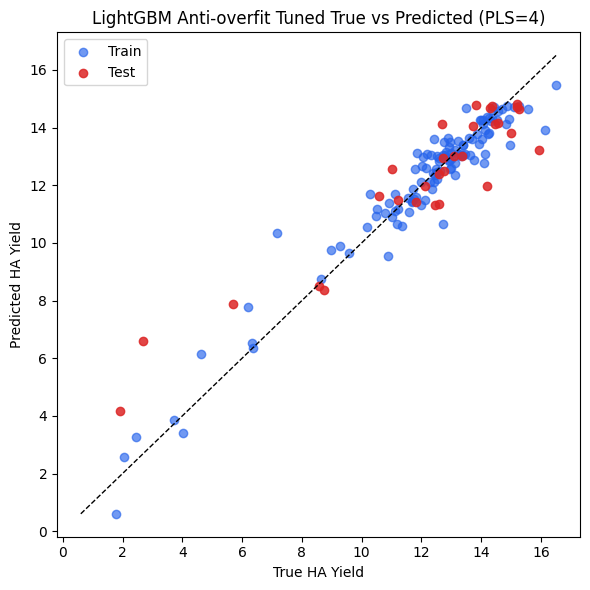

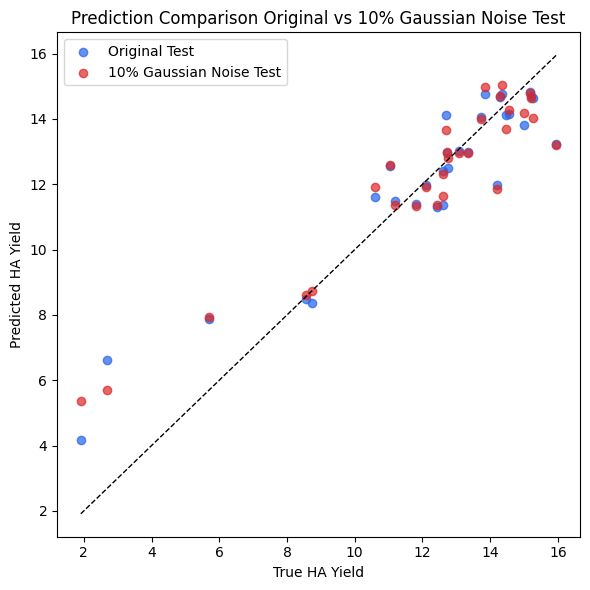

LightGBM Tuned Best Parameters:
{'reg_alpha': 0.1, 'colsample_bytree': 1.0, 'subsample': 1.0, 'subsample_freq': 0, 'linear_tree': True, 'learning_rate': 0.12, 'max_depth': 2, 'min_child_samples': 15, 'n_estimators': 80, 'num_leaves': 3, 'reg_lambda': 3.0}

PLS Components: 4
PLS Cumulative Variance Ratio: 97.2369%

===== Cross-Validation (5-fold Average) =====
MSE : 1.4053 ± 0.7165
RMSE: 1.1443 ± 0.3097
MAE : 0.8813 ± 0.2238
MRE : 10.57% ± 4.43%
R2  : 0.8170 ± 0.0501

===== Training Set Metrics =====
MSE: 0.4973
RMSE: 0.7052
MAE: 0.4938
MRE: 5.37%
R2: 0.9354

===== Test Set Metrics =====
MSE: 1.6725
RMSE: 1.2933
MAE: 0.9149
MRE: 14.87%
R2: 0.8567

===== Overfitting gap check (R2, threshold 0.15) =====
|CV-Train| = 0.1184
|CV-Test | = 0.0397
|Train-Test| = 0.0787
Max pairwise gap = 0.1184  ==> PASS (no overfitting)

===== Test Set With 10% Gaussian Noise =====
MSE: 1.7346
RMSE: 1.3171
MAE: 0.9403
MRE: 15.89%
R2: 0.8513
R2 reduction after noise: 0.0053

===== Permutation Importance Rankin

In [4]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import GroupShuffleSplit, GroupKFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance
from lightgbm import LGBMRegressor
from tqdm import tqdm

warnings.filterwarnings("ignore")

base_dir = Path.cwd()
spectra_path = base_dir / "pattern.xlsx"
label_path = base_dir / "label.xlsx"

if not spectra_path.exists():
    raise FileNotFoundError(f"Cannot find spectra file: {spectra_path}")
if not label_path.exists():
    raise FileNotFoundError(f"Cannot find label file: {label_path}")

output_path = spectra_path.with_name("LightGBM_noise.xlsx")
output_dir = spectra_path.parent / "lightgbm_pls4_tuned_visual"
output_dir.mkdir(exist_ok=True)
cv_predictions_dir = output_dir / "cv_fold_predictions"
cv_predictions_dir.mkdir(exist_ok=True)

spectra_df = pd.read_excel(spectra_path, header=None)
label_df = pd.read_excel(label_path, header=None)

id_col = "ID"
target_col = "HA Yield"
feature_cols = [f"Feature_{i}" for i in range(1, spectra_df.shape[1])]
spectra_df.columns = [id_col] + feature_cols
label_df = label_df.iloc[:, :2].copy()
label_df.columns = [id_col, target_col]

def normalize_id(x):
    if pd.isna(x):
        return np.nan
    if isinstance(x, (int, np.integer)):
        return str(x)
    if isinstance(x, (float, np.floating)):
        return str(int(x)) if x.is_integer() else str(x).rstrip("0").rstrip(".")
    return str(x).strip()

spectra_df[id_col] = spectra_df[id_col].map(normalize_id)
label_df[id_col] = label_df[id_col].map(normalize_id)
label_df[target_col] = pd.to_numeric(label_df[target_col], errors="coerce")

label_check = label_df.groupby(id_col)[target_col].nunique(dropna=False)
conflict_ids = label_check[label_check > 1].index.tolist()
if conflict_ids:
    raise ValueError(f"The following IDs have multiple different HA yields, please check label.xlsx: {conflict_ids}")

label_unique = label_df.drop_duplicates(subset=[id_col], keep="first")
df = spectra_df.merge(label_unique, on=id_col, how="left")

if df[target_col].isna().any():
    missing_ids = df.loc[df[target_col].isna(), id_col].unique()
    raise ValueError(f"The following IDs are not found in label.xlsx: {missing_ids}")

X = df[feature_cols].apply(pd.to_numeric, errors="coerce")
X = X.fillna(X.mean()).fillna(0)
y = df[target_col].astype(float)

X_standard = (X - X.mean(axis=0)) / X.std(axis=0, ddof=0).replace(0, 1)

n_components = 4
max_components = min(X_standard.shape[0] - 1, X_standard.shape[1])
if n_components > max_components:
    raise ValueError(f"At most {max_components} PLS components can be extracted, cannot set to {n_components}.")

pls = PLSRegression(n_components=n_components, scale=False)
pls.fit(X_standard.values, y.values.reshape(-1, 1))
X_scores = pls.x_scores_
X_reconstructed = X_scores @ pls.x_loadings_.T
ss_total = np.sum(X_standard.values ** 2)
ss_residual = np.sum((X_standard.values - X_reconstructed) ** 2)
cumulative_variance_ratio = 1 - ss_residual / ss_total

pls_cols = [f"PLS_Component_{i + 1}" for i in range(n_components)]
df_pls = pd.DataFrame(X_scores, columns=pls_cols)
df_pls.insert(0, id_col, df[id_col].values)
df_pls[target_col] = y.values

X_model = df_pls[pls_cols].astype(float)
y_model = df_pls[target_col].astype(float)
groups = df_pls[id_col].astype(str)

splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(splitter.split(X_model, y_model, groups=groups))
X_train = X_model.iloc[train_idx]
X_test = X_model.iloc[test_idx]
y_train = y_model.iloc[train_idx]
y_test = y_model.iloc[test_idx]
groups_train = groups.iloc[train_idx]

best_params = {
    'reg_alpha': 0.1,
    'colsample_bytree': 1.0,
    'subsample': 1.0,
    'subsample_freq': 0,
    'linear_tree': True,
    'learning_rate': 0.12,
    'max_depth': 2,
    'min_child_samples': 15,
    'n_estimators': 80,
    'num_leaves': 3,
    'reg_lambda': 3.0
}

print("\nBest parameters found by GridSearchCV:")
print(best_params)

n_splits = min(5, groups_train.nunique())
if n_splits < 2:
    raise ValueError("Not enough groups in training set for GroupKFold cross-validation.")
cv = GroupKFold(n_splits=n_splits)

cv_mse_scores, cv_rmse_scores, cv_mae_scores, cv_mre_scores, cv_r2_scores = [], [], [], [], []
cv_predictions = []

for fold_idx, (train_idx_cv, val_idx_cv) in enumerate(tqdm(cv.split(X_train, y_train, groups=groups_train), desc="5-Fold CV Evaluation Progress")):
    X_tr = X_train.iloc[train_idx_cv]
    y_tr = y_train.iloc[train_idx_cv]
    X_val = X_train.iloc[val_idx_cv]
    y_val = y_train.iloc[val_idx_cv]

    fold_model = LGBMRegressor(objective="regression", random_state=42, n_jobs=-1,
                               verbose=-1, **best_params)
    fold_model.fit(X_tr, y_tr)
    y_val_pred = fold_model.predict(X_val)

    mse_val = mean_squared_error(y_val, y_val_pred)
    rmse_val = np.sqrt(mse_val)
    mae_val = mean_absolute_error(y_val, y_val_pred)
    mre_val = np.mean(np.abs(y_val - y_val_pred) / y_val) * 100
    r2_val = r2_score(y_val, y_val_pred)

    cv_mse_scores.append(mse_val)
    cv_rmse_scores.append(rmse_val)
    cv_mae_scores.append(mae_val)
    cv_mre_scores.append(mre_val)
    cv_r2_scores.append(r2_val)

    fold_pred_df = pd.DataFrame({
        id_col: df_pls.iloc[train_idx].iloc[val_idx_cv][id_col].values,
        "Fold": f"Fold_{fold_idx + 1}",
        "True_HA_Yield": y_val.values,
        "Predicted_HA_Yield": y_val_pred,
        "Residual": y_val.values - y_val_pred,
        "Absolute_Error": np.abs(y_val.values - y_val_pred),
        "Relative_Error_%": np.abs(y_val.values - y_val_pred) / y_val.values * 100
    })
    cv_predictions.append(fold_pred_df)
    fold_output_path = cv_predictions_dir / f"fold_{fold_idx + 1}_predictions.xlsx"
    with pd.ExcelWriter(fold_output_path, engine="openpyxl") as writer:
        fold_pred_df.to_excel(writer, sheet_name="predictions", index=False)
        pd.DataFrame({"Metric": ["MSE", "RMSE", "MAE", "MRE_%", "R2"],
                      "Value": [mse_val, rmse_val, mae_val, mre_val, r2_val]}
                     ).to_excel(writer, sheet_name="metrics", index=False)
        pd.DataFrame({"Info": ["Training samples", "Validation samples", "Fold number"],
                      "Value": [len(X_tr), len(X_val), fold_idx + 1]}
                     ).to_excel(writer, sheet_name="info", index=False)

cv_mse, cv_rmse, cv_mae, cv_mre, cv_r2 = (np.mean(s) for s in
    (cv_mse_scores, cv_rmse_scores, cv_mae_scores, cv_mre_scores, cv_r2_scores))
cv_mse_std, cv_rmse_std, cv_mae_std, cv_mre_std, cv_r2_std = (np.std(s) for s in
    (cv_mse_scores, cv_rmse_scores, cv_mae_scores, cv_mre_scores, cv_r2_scores))

print("\n" + "="*60)
print("Cross-Validation Results for Each Fold (anti-overfit tuned):")
print("="*60)
for i in range(n_splits):
    print(f"\nFold {i+1}:  MSE {cv_mse_scores[i]:.4f} | RMSE {cv_rmse_scores[i]:.4f} | "
          f"MAE {cv_mae_scores[i]:.4f} | MRE {cv_mre_scores[i]:.2f}% | R2 {cv_r2_scores[i]:.4f}")

model = LGBMRegressor(objective="regression", random_state=42, n_jobs=-1, verbose=-1, **best_params)
model.fit(X_train, y_train)
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
train_rmse = np.sqrt(train_mse)
test_rmse = np.sqrt(test_mse)
train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)
train_mre = np.mean(np.abs(y_train - y_train_pred) / y_train) * 100
test_mre = np.mean(np.abs(y_test - y_test_pred) / y_test) * 100

gap_cv_tr = abs(cv_r2 - train_r2)
gap_cv_te = abs(cv_r2 - test_r2)
gap_tr_te = abs(train_r2 - test_r2)
max_r2_gap = max(gap_cv_tr, gap_cv_te, gap_tr_te)
overfit_pass = max_r2_gap < 0.15

train_result_df = pd.DataFrame({
    id_col: df_pls.iloc[train_idx][id_col].values, "Dataset": "Training",
    "True HA Yield": y_train.values, "Predicted HA Yield": y_train_pred})
test_result_df = pd.DataFrame({
    id_col: df_pls.iloc[test_idx][id_col].values, "Dataset": "Test",
    "True HA Yield": y_test.values, "Predicted HA Yield": y_test_pred})
all_result_df = pd.concat([train_result_df, test_result_df], axis=0).reset_index(drop=True)

def id_sort_key(x):
    try:
        return float(str(x).strip())
    except ValueError:
        return np.inf
all_result_df["Sort Key"] = all_result_df[id_col].map(id_sort_key)
all_result_df["Group Index"] = all_result_df.groupby(id_col).cumcount() + 1
all_result_sorted_df = all_result_df.sort_values(
    by=["Sort Key", "Group Index"], ascending=[True, True]).drop(columns=["Sort Key"])

metrics_df = pd.DataFrame({
    "Metric": ["PLS Components", "PLS Cumulative Variance Ratio",
        "CV MSE (Average)", "CV RMSE (Average)", "CV MAE (Average)", "CV MRE(%) (Average)", "CV R2 (Average)",
        "CV MSE (Std)", "CV RMSE (Std)", "CV MAE (Std)", "CV MRE(%) (Std)", "CV R2 (Std)",
        "Training MSE", "Test MSE", "Training RMSE", "Test RMSE", "Training MAE", "Test MAE",
        "Training MRE(%)", "Test MRE(%)", "Training R2", "Test R2",
        "|CV-Train R2 gap|", "|CV-Test R2 gap|", "|Train-Test R2 gap|", "Max pairwise R2 gap",
        "Overfit check (max gap < 0.15)"],
    "Value": [n_components, cumulative_variance_ratio,
        cv_mse, cv_rmse, cv_mae, cv_mre, cv_r2,
        cv_mse_std, cv_rmse_std, cv_mae_std, cv_mre_std, cv_r2_std,
        train_mse, test_mse, train_rmse, test_rmse, train_mae, test_mae,
        train_mre, test_mre, train_r2, test_r2,
        gap_cv_tr, gap_cv_te, gap_tr_te, max_r2_gap, "PASS" if overfit_pass else "FAIL"]
})
best_params_df = pd.DataFrame(list(best_params.items()), columns=["Parameter", "Best Value"])
feature_importance_df = pd.DataFrame({"Feature": pls_cols, "Importance": model.feature_importances_}
                                     ).sort_values("Importance", ascending=False)

perm_result = permutation_importance(
    estimator=model,
    X=X_test,
    y=y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)
perm_importance_df = pd.DataFrame({
    "Feature": pls_cols,
    "Permutation_Importance_Mean": perm_result.importances_mean,
    "Permutation_Importance_Std": perm_result.importances_std,
    "Permutation_Importance_Std_Square": perm_result.importances_std ** 2
}).sort_values("Permutation_Importance_Mean", ascending=False)

plt.figure(figsize=(6, 6))
plt.scatter(y_train, y_train_pred, alpha=0.65, label="Train", color="#2563EB")
plt.scatter(y_test, y_test_pred, alpha=0.85, label="Test", color="#DC2626")
min_v = min(y_train.min(), y_test.min(), y_train_pred.min(), y_test_pred.min())
max_v = max(y_train.max(), y_test.max(), y_train_pred.max(), y_test_pred.max())
plt.plot([min_v, max_v], [min_v, max_v], "k--", linewidth=1)
plt.xlabel("True HA Yield")
plt.ylabel("Predicted HA Yield")
plt.title("LightGBM Anti-overfit Tuned True vs Predicted (PLS=4)")
plt.legend()
plt.tight_layout()
plt.savefig(output_dir / "true_vs_predicted_train_test.png", dpi=300)
plt.show()

noise_level = 0.3
np.random.seed(42)
X_standard_test = X_standard.iloc[test_idx].copy().values
noise = np.random.normal(0, noise_level, X_standard_test.shape)
X_standard_test_noisy = X_standard_test + noise

X_noise_pls = pls.transform(X_standard_test_noisy)
X_noise_df = pd.DataFrame(X_noise_pls, columns=pls_cols)
y_test_noise_pred = model.predict(X_noise_df)

noise_test_mse = mean_squared_error(y_test, y_test_noise_pred)
noise_test_rmse = np.sqrt(noise_test_mse)
noise_test_mae = mean_absolute_error(y_test, y_test_noise_pred)
noise_test_mre = np.mean(np.abs(y_test - y_test_noise_pred) / y_test) * 100
noise_test_r2 = r2_score(y_test, y_test_noise_pred)

noise_metrics_df = pd.DataFrame({
    "Metric": [
        "Noise Type", "Noise Level",
        "Original Test MSE", "Noisy Test MSE",
        "Original Test RMSE", "Noisy Test RMSE",
        "Original Test MAE", "Noisy Test MAE",
        "Original Test MRE(%)", "Noisy Test MRE(%)",
        "Original Test R2", "Noisy Test R2",
        "R2 Drop After Noise"
    ],
    "Value": [
        "10% Gaussian Noise", f"{noise_level*100}%",
        test_mse, noise_test_mse,
        test_rmse, noise_test_rmse,
        test_mae, noise_test_mae,
        test_mre, noise_test_mre,
        test_r2, noise_test_r2,
        test_r2 - noise_test_r2
    ]
})

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_test_pred, alpha=0.7, label="Original Test", color="#2563EB")
plt.scatter(y_test, y_test_noise_pred, alpha=0.7, label="10% Gaussian Noise Test", color="#DC2626")
min_all = min(y_test.min(), y_test_pred.min(), y_test_noise_pred.min())
max_all = max(y_test.max(), y_test_pred.max(), y_test_noise_pred.max())
plt.plot([min_all, max_all], [min_all, max_all], "k--", lw=1)
plt.xlabel("True HA Yield")
plt.ylabel("Predicted HA Yield")
plt.title("Prediction Comparison Original vs 10% Gaussian Noise Test")
plt.legend()
plt.tight_layout()
plt.savefig(output_dir / "noise_comparison_scatter.png", dpi=300)
plt.show()

noisy_test_df = pd.DataFrame({
    id_col: df_pls.iloc[test_idx][id_col].values,
    "True HA Yield": y_test.values,
    "Noisy Predicted HA Yield": y_test_noise_pred
})

with pd.ExcelWriter(output_path, engine="openpyxl") as writer:
    df_pls.to_excel(writer, sheet_name="pls_scores_4", index=False)
    train_result_df.to_excel(writer, sheet_name="train_predictions", index=False)
    test_result_df.to_excel(writer, sheet_name="test_predictions", index=False)
    all_result_sorted_df.to_excel(writer, sheet_name="all_predictions_by_id", index=False)
    metrics_df.to_excel(writer, sheet_name="metrics", index=False)
    best_params_df.to_excel(writer, sheet_name="best_params", index=False)
    feature_importance_df.to_excel(writer, sheet_name="lgbm_gain_importance", index=False)
    perm_importance_df.to_excel(writer, sheet_name="permutation_importance", index=False)
    noise_metrics_df.to_excel(writer, sheet_name="noise_robustness_metrics", index=False)
    noisy_test_df.to_excel(writer, sheet_name="noisy_test_predictions", index=False)
    for fold_pred_df in cv_predictions:
        fold_pred_df.to_excel(writer, sheet_name=f"{fold_pred_df['Fold'].iloc[0]}_predictions", index=False)
    pd.DataFrame({"Fold": [f"Fold_{i+1}" for i in range(n_splits)], "MSE": cv_mse_scores,
                  "RMSE": cv_rmse_scores, "MAE": cv_mae_scores, "MRE_%": cv_mre_scores,
                  "R2": cv_r2_scores}).to_excel(writer, sheet_name="cv_fold_summary", index=False)

cv_predictions_summary_path = output_dir / "all_cv_fold_predictions.xlsx"
with pd.ExcelWriter(cv_predictions_summary_path, engine="openpyxl") as writer:
    for fold_pred_df in cv_predictions:
        fold_pred_df.to_excel(writer, sheet_name=fold_pred_df["Fold"].iloc[0], index=False)
    pd.DataFrame({"Fold": [f"Fold_{i+1}" for i in range(n_splits)], "MSE": cv_mse_scores,
                  "RMSE": cv_rmse_scores, "MAE": cv_mae_scores, "MRE_%": cv_mre_scores,
                  "R2": cv_r2_scores}).to_excel(writer, sheet_name="summary", index=False)

print("="*60)
print("LightGBM Tuned Best Parameters:")
print(best_params)
print(f"\nPLS Components: {n_components}")
print(f"PLS Cumulative Variance Ratio: {cumulative_variance_ratio:.4%}")
print("\n===== Cross-Validation (5-fold Average) =====")
print(f"MSE : {cv_mse:.4f} ± {cv_mse_std:.4f}")
print(f"RMSE: {cv_rmse:.4f} ± {cv_rmse_std:.4f}")
print(f"MAE : {cv_mae:.4f} ± {cv_mae_std:.4f}")
print(f"MRE : {cv_mre:.2f}% ± {cv_mre_std:.2f}%")
print(f"R2  : {cv_r2:.4f} ± {cv_r2_std:.4f}")
print(f"\n===== Training Set Metrics =====")
print(f"MSE: {train_mse:.4f}\nRMSE: {train_rmse:.4f}\nMAE: {train_mae:.4f}\nMRE: {train_mre:.2f}%\nR2: {train_r2:.4f}")
print(f"\n===== Test Set Metrics =====")
print(f"MSE: {test_mse:.4f}\nRMSE: {test_rmse:.4f}\nMAE: {test_mae:.4f}\nMRE: {test_mre:.2f}%\nR2: {test_r2:.4f}")
print("\n===== Overfitting gap check (R2, threshold 0.15) =====")
print(f"|CV-Train| = {gap_cv_tr:.4f}")
print(f"|CV-Test | = {gap_cv_te:.4f}")
print(f"|Train-Test| = {gap_tr_te:.4f}")
print(f"Max pairwise gap = {max_r2_gap:.4f}  ==> {'PASS (no overfitting)' if overfit_pass else 'FAIL (still overfitting)'}")
print(f"\n===== Test Set With 10% Gaussian Noise =====")
print(f"MSE: {noise_test_mse:.4f}")
print(f"RMSE: {noise_test_rmse:.4f}")
print(f"MAE: {noise_test_mae:.4f}")
print(f"MRE: {noise_test_mre:.2f}%")
print(f"R2: {noise_test_r2:.4f}")
print(f"R2 reduction after noise: {(test_r2 - noise_test_r2):.4f}")
print("\n===== Permutation Importance Ranking (Test Set) =====")
print(perm_importance_df.to_string(index=False))


Best parameters found by GridSearchCV:
{'reg_alpha': 0.1, 'colsample_bytree': 1.0, 'subsample': 1.0, 'subsample_freq': 0, 'linear_tree': True, 'learning_rate': 0.12, 'max_depth': 2, 'min_child_samples': 15, 'n_estimators': 80, 'num_leaves': 3, 'reg_lambda': 3.0}


5-Fold CV Evaluation Progress: 5it [00:00, 30.73it/s]


Cross-Validation Results for Each Fold (anti-overfit tuned):

Fold 1:  MSE 1.2698 | RMSE 1.1269 | MAE 0.8992 | MRE 11.76% | R2 0.8798

Fold 2:  MSE 0.6021 | RMSE 0.7760 | MAE 0.6041 | MRE 5.55% | R2 0.8723

Fold 3:  MSE 0.6946 | RMSE 0.8334 | MAE 0.6996 | MRE 5.81% | R2 0.8007

Fold 4:  MSE 2.0932 | RMSE 1.4468 | MAE 0.9550 | MRE 17.31% | R2 0.7607

Fold 5:  MSE 2.3670 | RMSE 1.5385 | MAE 1.2485 | MRE 12.40% | R2 0.7713


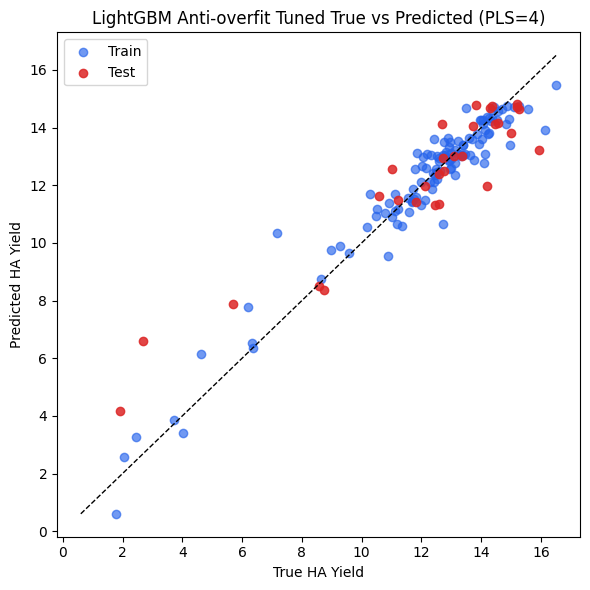

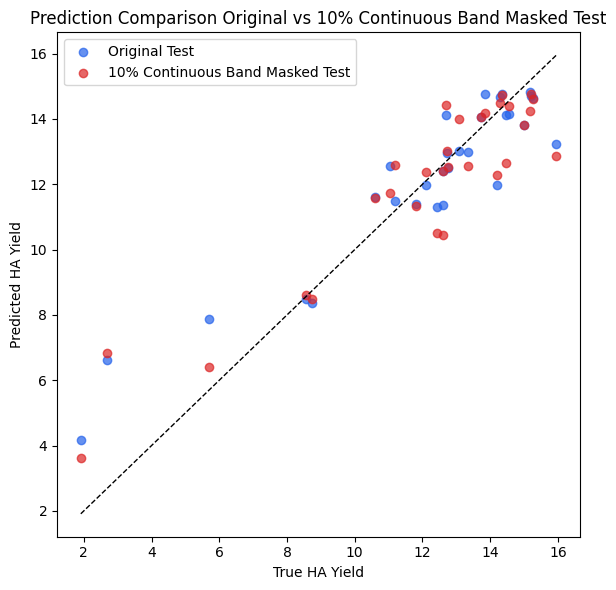

LightGBM Tuned Best Parameters:
{'reg_alpha': 0.1, 'colsample_bytree': 1.0, 'subsample': 1.0, 'subsample_freq': 0, 'linear_tree': True, 'learning_rate': 0.12, 'max_depth': 2, 'min_child_samples': 15, 'n_estimators': 80, 'num_leaves': 3, 'reg_lambda': 3.0}

PLS Components: 4
PLS Cumulative Variance Ratio: 97.2369%
Total spectral bands: 512
Continuous masked band length per sample: 51

===== Cross-Validation (5-fold Average) =====
MSE : 1.4053 ± 0.7165
RMSE: 1.1443 ± 0.3097
MAE : 0.8813 ± 0.2238
MRE : 10.57% ± 4.43%
R2  : 0.8170 ± 0.0501

===== Training Set Metrics =====
MSE: 0.4973
RMSE: 0.7052
MAE: 0.4938
MRE: 5.37%
R2: 0.9354

===== Test Set Metrics =====
MSE: 1.6725
RMSE: 1.2933
MAE: 0.9149
MRE: 14.87%
R2: 0.8567

===== Overfitting gap check (R2, threshold 0.15) =====
|CV-Train| = 0.1184
|CV-Test | = 0.0397
|Train-Test| = 0.0787
Max pairwise gap = 0.1184  ==> PASS (no overfitting)

===== Test Set With 10% Continuous Spectral Band Masking =====
MSE: 1.9116
RMSE: 1.3826
MAE: 1.0131
MRE

In [6]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import GroupShuffleSplit, GroupKFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance
from lightgbm import LGBMRegressor
from tqdm import tqdm

warnings.filterwarnings("ignore")

base_dir = Path.cwd()
spectra_path = base_dir / "pattern.xlsx"
label_path = base_dir / "label.xlsx"

if not spectra_path.exists():
    raise FileNotFoundError(f"Cannot find spectra file: {spectra_path}")
if not label_path.exists():
    raise FileNotFoundError(f"Cannot find label file: {label_path}")

output_path = spectra_path.with_name("LightGBM_tuned.xlsx")
output_dir = spectra_path.parent / "lightgbm_pls4_tuned_visual"
output_dir.mkdir(exist_ok=True)
cv_predictions_dir = output_dir / "cv_fold_predictions"
cv_predictions_dir.mkdir(exist_ok=True)

spectra_df = pd.read_excel(spectra_path, header=None)
label_df = pd.read_excel(label_path, header=None)

id_col = "ID"
target_col = "HA Yield"
feature_cols = [f"Feature_{i}" for i in range(1, spectra_df.shape[1])]
spectra_df.columns = [id_col] + feature_cols
label_df = label_df.iloc[:, :2].copy()
label_df.columns = [id_col, target_col]

def normalize_id(x):
    if pd.isna(x):
        return np.nan
    if isinstance(x, (int, np.integer)):
        return str(x)
    if isinstance(x, (float, np.floating)):
        return str(int(x)) if x.is_integer() else str(x).rstrip("0").rstrip(".")
    return str(x).strip()

spectra_df[id_col] = spectra_df[id_col].map(normalize_id)
label_df[id_col] = label_df[id_col].map(normalize_id)
label_df[target_col] = pd.to_numeric(label_df[target_col], errors="coerce")

label_check = label_df.groupby(id_col)[target_col].nunique(dropna=False)
conflict_ids = label_check[label_check > 1].index.tolist()
if conflict_ids:
    raise ValueError(f"The following IDs have multiple different HA yields, please check label.xlsx: {conflict_ids}")

label_unique = label_df.drop_duplicates(subset=[id_col], keep="first")
df = spectra_df.merge(label_unique, on=id_col, how="left")

if df[target_col].isna().any():
    missing_ids = df.loc[df[target_col].isna(), id_col].unique()
    raise ValueError(f"The following IDs are not found in label.xlsx: {missing_ids}")

X = df[feature_cols].apply(pd.to_numeric, errors="coerce")
X = X.fillna(X.mean()).fillna(0)
y = df[target_col].astype(float)

X_standard = (X - X.mean(axis=0)) / X.std(axis=0, ddof=0).replace(0, 1)

n_components = 4
max_components = min(X_standard.shape[0] - 1, X_standard.shape[1])
if n_components > max_components:
    raise ValueError(f"At most {max_components} PLS components can be extracted, cannot set to {n_components}.")

pls = PLSRegression(n_components=n_components, scale=False)
pls.fit(X_standard.values, y.values.reshape(-1, 1))
X_scores = pls.x_scores_
X_reconstructed = X_scores @ pls.x_loadings_.T
ss_total = np.sum(X_standard.values ** 2)
ss_residual = np.sum((X_standard.values - X_reconstructed) ** 2)
cumulative_variance_ratio = 1 - ss_residual / ss_total

pls_cols = [f"PLS_Component_{i + 1}" for i in range(n_components)]
df_pls = pd.DataFrame(X_scores, columns=pls_cols)
df_pls.insert(0, id_col, df[id_col].values)
df_pls[target_col] = y.values

X_model = df_pls[pls_cols].astype(float)
y_model = df_pls[target_col].astype(float)
groups = df_pls[id_col].astype(str)

splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(splitter.split(X_model, y_model, groups=groups))
X_train = X_model.iloc[train_idx]
X_test = X_model.iloc[test_idx]
y_train = y_model.iloc[train_idx]
y_test = y_model.iloc[test_idx]
groups_train = groups.iloc[train_idx]

best_params = {
    'reg_alpha': 0.1,
    'colsample_bytree': 1.0,
    'subsample': 1.0,
    'subsample_freq': 0,
    'linear_tree': True,
    'learning_rate': 0.12,
    'max_depth': 2,
    'min_child_samples': 15,
    'n_estimators': 80,
    'num_leaves': 3,
    'reg_lambda': 3.0
}

print("\nBest parameters found by GridSearchCV:")
print(best_params)

n_splits = min(5, groups_train.nunique())
if n_splits < 2:
    raise ValueError("Not enough groups in training set for GroupKFold cross-validation.")
cv = GroupKFold(n_splits=n_splits)

cv_mse_scores, cv_rmse_scores, cv_mae_scores, cv_mre_scores, cv_r2_scores = [], [], [], [], []
cv_predictions = []

for fold_idx, (train_idx_cv, val_idx_cv) in enumerate(tqdm(cv.split(X_train, y_train, groups=groups_train), desc="5-Fold CV Evaluation Progress")):
    X_tr = X_train.iloc[train_idx_cv]
    y_tr = y_train.iloc[train_idx_cv]
    X_val = X_train.iloc[val_idx_cv]
    y_val = y_train.iloc[val_idx_cv]

    fold_model = LGBMRegressor(objective="regression", random_state=42, n_jobs=-1,
                               verbose=-1, **best_params)
    fold_model.fit(X_tr, y_tr)
    y_val_pred = fold_model.predict(X_val)

    mse_val = mean_squared_error(y_val, y_val_pred)
    rmse_val = np.sqrt(mse_val)
    mae_val = mean_absolute_error(y_val, y_val_pred)
    mre_val = np.mean(np.abs(y_val - y_val_pred) / y_val) * 100
    r2_val = r2_score(y_val, y_val_pred)

    cv_mse_scores.append(mse_val)
    cv_rmse_scores.append(rmse_val)
    cv_mae_scores.append(mae_val)
    cv_mre_scores.append(mre_val)
    cv_r2_scores.append(r2_val)

    fold_pred_df = pd.DataFrame({
        id_col: df_pls.iloc[train_idx].iloc[val_idx_cv][id_col].values,
        "Fold": f"Fold_{fold_idx + 1}",
        "True_HA_Yield": y_val.values,
        "Predicted_HA_Yield": y_val_pred,
        "Residual": y_val.values - y_val_pred,
        "Absolute_Error": np.abs(y_val.values - y_val_pred),
        "Relative_Error_%": np.abs(y_val.values - y_val_pred) / y_val.values * 100
    })
    cv_predictions.append(fold_pred_df)
    fold_output_path = cv_predictions_dir / f"fold_{fold_idx + 1}_predictions.xlsx"
    with pd.ExcelWriter(fold_output_path, engine="openpyxl") as writer:
        fold_pred_df.to_excel(writer, sheet_name="predictions", index=False)
        pd.DataFrame({"Metric": ["MSE", "RMSE", "MAE", "MRE_%", "R2"],
                      "Value": [mse_val, rmse_val, mae_val, mre_val, r2_val]}
                     ).to_excel(writer, sheet_name="metrics", index=False)
        pd.DataFrame({"Info": ["Training samples", "Validation samples", "Fold number"],
                      "Value": [len(X_tr), len(X_val), fold_idx + 1]}
                     ).to_excel(writer, sheet_name="info", index=False)

cv_mse, cv_rmse, cv_mae, cv_mre, cv_r2 = (np.mean(s) for s in
    (cv_mse_scores, cv_rmse_scores, cv_mae_scores, cv_mre_scores, cv_r2_scores))
cv_mse_std, cv_rmse_std, cv_mae_std, cv_mre_std, cv_r2_std = (np.std(s) for s in
    (cv_mse_scores, cv_rmse_scores, cv_mae_scores, cv_mre_scores, cv_r2_scores))

print("\n" + "="*60)
print("Cross-Validation Results for Each Fold (anti-overfit tuned):")
print("="*60)
for i in range(n_splits):
    print(f"\nFold {i+1}:  MSE {cv_mse_scores[i]:.4f} | RMSE {cv_rmse_scores[i]:.4f} | "
          f"MAE {cv_mae_scores[i]:.4f} | MRE {cv_mre_scores[i]:.2f}% | R2 {cv_r2_scores[i]:.4f}")

model = LGBMRegressor(objective="regression", random_state=42, n_jobs=-1, verbose=-1, **best_params)
model.fit(X_train, y_train)
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
train_rmse = np.sqrt(train_mse)
test_rmse = np.sqrt(test_mse)
train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)
train_mre = np.mean(np.abs(y_train - y_train_pred) / y_train) * 100
test_mre = np.mean(np.abs(y_test - y_test_pred) / y_test) * 100

gap_cv_tr = abs(cv_r2 - train_r2)
gap_cv_te = abs(cv_r2 - test_r2)
gap_tr_te = abs(train_r2 - test_r2)
max_r2_gap = max(gap_cv_tr, gap_cv_te, gap_tr_te)
overfit_pass = max_r2_gap < 0.15

train_result_df = pd.DataFrame({
    id_col: df_pls.iloc[train_idx][id_col].values, "Dataset": "Training",
    "True HA Yield": y_train.values, "Predicted HA Yield": y_train_pred})
test_result_df = pd.DataFrame({
    id_col: df_pls.iloc[test_idx][id_col].values, "Dataset": "Test",
    "True HA Yield": y_test.values, "Predicted HA Yield": y_test_pred})
all_result_df = pd.concat([train_result_df, test_result_df], axis=0).reset_index(drop=True)

def id_sort_key(x):
    try:
        return float(str(x).strip())
    except ValueError:
        return np.inf
all_result_df["Sort Key"] = all_result_df[id_col].map(id_sort_key)
all_result_df["Group Index"] = all_result_df.groupby(id_col).cumcount() + 1
all_result_sorted_df = all_result_df.sort_values(
    by=["Sort Key", "Group Index"], ascending=[True, True]).drop(columns=["Sort Key"])

metrics_df = pd.DataFrame({
    "Metric": ["PLS Components", "PLS Cumulative Variance Ratio",
        "CV MSE (Average)", "CV RMSE (Average)", "CV MAE (Average)", "CV MRE(%) (Average)", "CV R2 (Average)",
        "CV MSE (Std)", "CV RMSE (Std)", "CV MAE (Std)", "CV MRE(%) (Std)", "CV R2 (Std)",
        "Training MSE", "Test MSE", "Training RMSE", "Test RMSE", "Training MAE", "Test MAE",
        "Training MRE(%)", "Test MRE(%)", "Training R2", "Test R2",
        "|CV-Train R2 gap|", "|CV-Test R2 gap|", "|Train-Test R2 gap|", "Max pairwise R2 gap",
        "Overfit check (max gap < 0.15)"],
    "Value": [n_components, cumulative_variance_ratio,
        cv_mse, cv_rmse, cv_mae, cv_mre, cv_r2,
        cv_mse_std, cv_rmse_std, cv_mae_std, cv_mre_std, cv_r2_std,
        train_mse, test_mse, train_rmse, test_rmse, train_mae, test_mae,
        train_mre, test_mre, train_r2, test_r2,
        gap_cv_tr, gap_cv_te, gap_tr_te, max_r2_gap, "PASS" if overfit_pass else "FAIL"]
})
best_params_df = pd.DataFrame(list(best_params.items()), columns=["Parameter", "Best Value"])
feature_importance_df = pd.DataFrame({"Feature": pls_cols, "Importance": model.feature_importances_}
                                     ).sort_values("Importance", ascending=False)

perm_result = permutation_importance(
    estimator=model,
    X=X_test,
    y=y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)
perm_importance_df = pd.DataFrame({
    "Feature": pls_cols,
    "Permutation_Importance_Mean": perm_result.importances_mean,
    "Permutation_Importance_Std": perm_result.importances_std,
    "Permutation_Importance_Std_Square": perm_result.importances_std ** 2
}).sort_values("Permutation_Importance_Mean", ascending=False)

plt.figure(figsize=(6, 6))
plt.scatter(y_train, y_train_pred, alpha=0.65, label="Train", color="#2563EB")
plt.scatter(y_test, y_test_pred, alpha=0.85, label="Test", color="#DC2626")
min_v = min(y_train.min(), y_test.min(), y_train_pred.min(), y_test_pred.min())
max_v = max(y_train.max(), y_test.max(), y_train_pred.max(), y_test_pred.max())
plt.plot([min_v, max_v], [min_v, max_v], "k--", linewidth=1)
plt.xlabel("True HA Yield")
plt.ylabel("Predicted HA Yield")
plt.title("LightGBM Anti-overfit Tuned True vs Predicted (PLS=4)")
plt.legend()
plt.tight_layout()
plt.savefig(output_dir / "true_vs_predicted_train_test.png", dpi=300)
plt.show()

mask_ratio = 0.10
np.random.seed(42)
X_standard_test = X_standard.iloc[test_idx].copy().values
n_sample, n_wave = X_standard_test.shape
window_len = int(n_wave * mask_ratio)

for i in range(n_sample):
    start = np.random.randint(0, n_wave - window_len + 1)
    X_standard_test[i, start:start + window_len] = 0.0

X_mask_pls = pls.transform(X_standard_test)
X_mask_df = pd.DataFrame(X_mask_pls, columns=pls_cols)
y_test_mask_pred = model.predict(X_mask_df)

mask_test_mse = mean_squared_error(y_test, y_test_mask_pred)
mask_test_rmse = np.sqrt(mask_test_mse)
mask_test_mae = mean_absolute_error(y_test, y_test_mask_pred)
mask_test_mre = np.mean(np.abs(y_test - y_test_mask_pred) / y_test) * 100
mask_test_r2 = r2_score(y_test, y_test_mask_pred)

mask_metrics_df = pd.DataFrame({
    "Metric": [
        "Mask Type", "Mask Ratio", "Continuous Mask Window Length",
        "Original Test MSE", "Masked Test MSE",
        "Original Test RMSE", "Masked Test RMSE",
        "Original Test MAE", "Masked Test MAE",
        "Original Test MRE(%)", "Masked Test MRE(%)",
        "Original Test R2", "Masked Test R2",
        "R2 Drop After Masking"
    ],
    "Value": [
        "10% Continuous Spectral Band Mask", f"{mask_ratio*100}%", window_len,
        test_mse, mask_test_mse,
        test_rmse, mask_test_rmse,
        test_mae, mask_test_mae,
        test_mre, mask_test_mre,
        test_r2, mask_test_r2,
        test_r2 - mask_test_r2
    ]
})

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_test_pred, alpha=0.7, label="Original Test", color="#2563EB")
plt.scatter(y_test, y_test_mask_pred, alpha=0.7, label="10% Continuous Band Masked Test", color="#DC2626")
min_all = min(y_test.min(), y_test_pred.min(), y_test_mask_pred.min())
max_all = max(y_test.max(), y_test_pred.max(), y_test_mask_pred.max())
plt.plot([min_all, max_all], [min_all, max_all], "k--", lw=1)
plt.xlabel("True HA Yield")
plt.ylabel("Predicted HA Yield")
plt.title("Prediction Comparison Original vs 10% Continuous Band Masked Test")
plt.legend()
plt.tight_layout()
plt.savefig(output_dir / "mask_comparison_scatter.png", dpi=300)
plt.show()

masked_test_df = pd.DataFrame({
    id_col: df_pls.iloc[test_idx][id_col].values,
    "True HA Yield": y_test.values,
    "Masked Predicted HA Yield": y_test_mask_pred
})

with pd.ExcelWriter(output_path, engine="openpyxl") as writer:
    df_pls.to_excel(writer, sheet_name="pls_scores_4", index=False)
    train_result_df.to_excel(writer, sheet_name="train_predictions", index=False)
    test_result_df.to_excel(writer, sheet_name="test_predictions", index=False)
    all_result_sorted_df.to_excel(writer, sheet_name="all_predictions_by_id", index=False)
    metrics_df.to_excel(writer, sheet_name="metrics", index=False)
    best_params_df.to_excel(writer, sheet_name="best_params", index=False)
    feature_importance_df.to_excel(writer, sheet_name="lgbm_gain_importance", index=False)
    perm_importance_df.to_excel(writer, sheet_name="permutation_importance", index=False)
    mask_metrics_df.to_excel(writer, sheet_name="mask_robustness_metrics", index=False)
    masked_test_df.to_excel(writer, sheet_name="masked_test_predictions", index=False)
    for fold_pred_df in cv_predictions:
        fold_pred_df.to_excel(writer, sheet_name=f"{fold_pred_df['Fold'].iloc[0]}_predictions", index=False)
    pd.DataFrame({"Fold": [f"Fold_{i+1}" for i in range(n_splits)], "MSE": cv_mse_scores,
                  "RMSE": cv_rmse_scores, "MAE": cv_mae_scores, "MRE_%": cv_mre_scores,
                  "R2": cv_r2_scores}).to_excel(writer, sheet_name="cv_fold_summary", index=False)

cv_predictions_summary_path = output_dir / "all_cv_fold_predictions.xlsx"
with pd.ExcelWriter(cv_predictions_summary_path, engine="openpyxl") as writer:
    for fold_pred_df in cv_predictions:
        fold_pred_df.to_excel(writer, sheet_name=fold_pred_df["Fold"].iloc[0], index=False)
    pd.DataFrame({"Fold": [f"Fold_{i+1}" for i in range(n_splits)], "MSE": cv_mse_scores,
                  "RMSE": cv_rmse_scores, "MAE": cv_mae_scores, "MRE_%": cv_mre_scores,
                  "R2": cv_r2_scores}).to_excel(writer, sheet_name="summary", index=False)

print("="*60)
print("LightGBM Tuned Best Parameters:")
print(best_params)
print(f"\nPLS Components: {n_components}")
print(f"PLS Cumulative Variance Ratio: {cumulative_variance_ratio:.4%}")
print(f"Total spectral bands: {n_wave}")
print(f"Continuous masked band length per sample: {window_len}")
print("\n===== Cross-Validation (5-fold Average) =====")
print(f"MSE : {cv_mse:.4f} ± {cv_mse_std:.4f}")
print(f"RMSE: {cv_rmse:.4f} ± {cv_rmse_std:.4f}")
print(f"MAE : {cv_mae:.4f} ± {cv_mae_std:.4f}")
print(f"MRE : {cv_mre:.2f}% ± {cv_mre_std:.2f}%")
print(f"R2  : {cv_r2:.4f} ± {cv_r2_std:.4f}")
print(f"\n===== Training Set Metrics =====")
print(f"MSE: {train_mse:.4f}\nRMSE: {train_rmse:.4f}\nMAE: {train_mae:.4f}\nMRE: {train_mre:.2f}%\nR2: {train_r2:.4f}")
print(f"\n===== Test Set Metrics =====")
print(f"MSE: {test_mse:.4f}\nRMSE: {test_rmse:.4f}\nMAE: {test_mae:.4f}\nMRE: {test_mre:.2f}%\nR2: {test_r2:.4f}")
print("\n===== Overfitting gap check (R2, threshold 0.15) =====")
print(f"|CV-Train| = {gap_cv_tr:.4f}")
print(f"|CV-Test | = {gap_cv_te:.4f}")
print(f"|Train-Test| = {gap_tr_te:.4f}")
print(f"Max pairwise gap = {max_r2_gap:.4f}  ==> {'PASS (no overfitting)' if overfit_pass else 'FAIL (still overfitting)'}")
print(f"\n===== Test Set With 10% Continuous Spectral Band Masking =====")
print(f"MSE: {mask_test_mse:.4f}")
print(f"RMSE: {mask_test_rmse:.4f}")
print(f"MAE: {mask_test_mae:.4f}")
print(f"MRE: {mask_test_mre:.2f}%")
print(f"R2: {mask_test_r2:.4f}")
print(f"R2 reduction after masking: {(test_r2 - mask_test_r2):.4f}")
print("\n===== Permutation Importance Ranking (Test Set) =====")
print(perm_importance_df.to_string(index=False))


Best parameters found by GridSearchCV:
{'reg_alpha': 0.1, 'colsample_bytree': 1.0, 'subsample': 1.0, 'subsample_freq': 0, 'linear_tree': True, 'learning_rate': 0.12, 'max_depth': 2, 'min_child_samples': 15, 'n_estimators': 80, 'num_leaves': 3, 'reg_lambda': 3.0}

Seed list:
[126, 135, 168, 174, 182, 184, 252, 329, 360, 394, 450, 550, 707, 731, 795, 846, 858, 878, 887, 890, 892, 986, 1010, 1032, 1079, 1100, 1257, 1272, 1279, 1355, 1366, 1396, 1410, 1445, 1495, 1510, 1511, 1544, 1546, 1557, 1628, 1646, 1654, 1680, 1706, 1763, 1785, 1830, 1915, 1938]
Average Test R2: 0.8537 ± 0.0344
Average Train R2: 0.9372 ± 0.0049
Average Train-Test R2 Gap: 0.0835 ± 0.0376


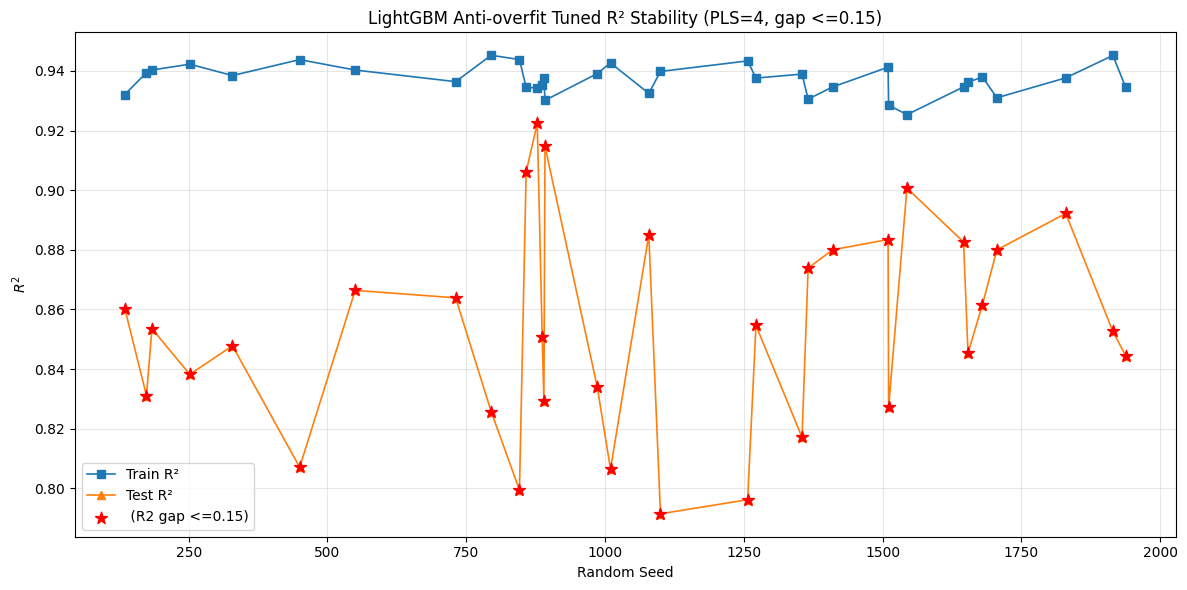

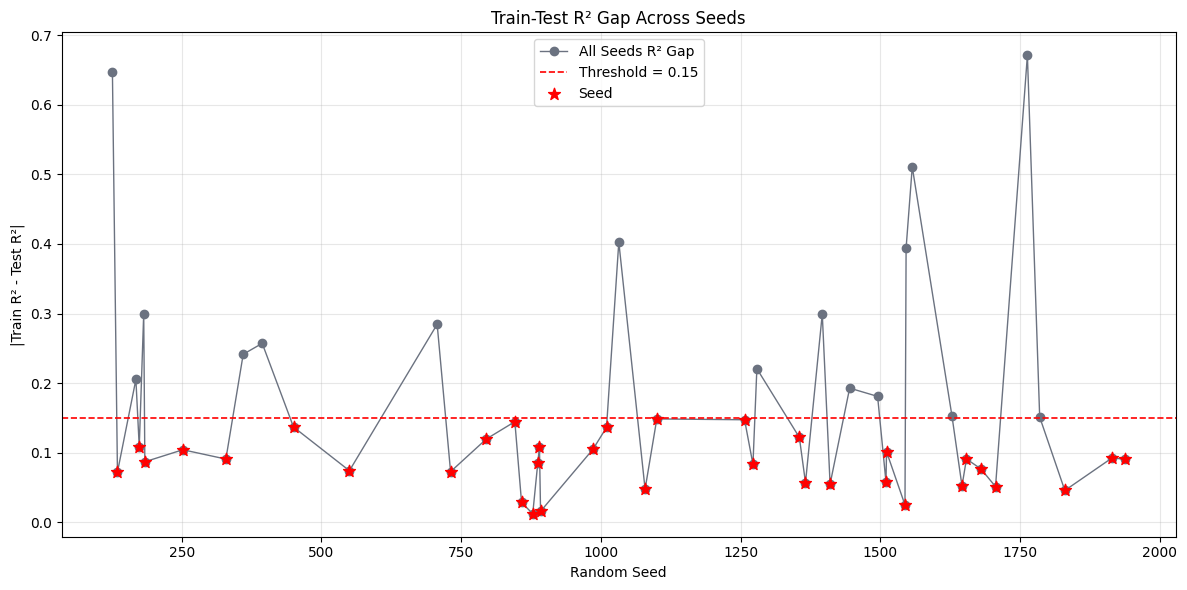

In [11]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from lightgbm import LGBMRegressor

warnings.filterwarnings("ignore")

best_params = {
    'reg_alpha': 0.1,
    'colsample_bytree': 1.0,
    'subsample': 1.0,
    'subsample_freq': 0,
    'linear_tree': True,
    'learning_rate': 0.12,
    'max_depth': 2,
    'min_child_samples': 15,
    'n_estimators': 80,
    'num_leaves': 3,
    'reg_lambda': 3.0
}
n_components = 4
rng = np.random.default_rng(42)
seed_list = sorted(rng.choice(np.arange(0, 2001), size=50, replace=False).tolist())
r2_diff_threshold = 0.15

base_dir = Path.cwd()
spectra_path = base_dir / "pattern.xlsx"
label_path = base_dir / "label.xlsx"

if not spectra_path.exists():
    raise FileNotFoundError(f"Cannot find spectra file: {spectra_path}")
if not label_path.exists():
    raise FileNotFoundError(f"Cannot find label file: {label_path}")

output_path = spectra_path.with_name("LightGBM_SeedStabilityResult.xlsx")
output_dir = spectra_path.parent / "lightgbm_pls4_tuned_visual"
output_dir.mkdir(exist_ok=True)

spectra_df = pd.read_excel(spectra_path, header=None)
label_df = pd.read_excel(label_path, header=None)

id_col = "ID"
target_col = "HA Yield"
feature_cols = [f"Feature_{i}" for i in range(1, spectra_df.shape[1])]
spectra_df.columns = [id_col] + feature_cols
label_df = label_df.iloc[:, :2].copy()
label_df.columns = [id_col, target_col]

def normalize_id(x):
    if pd.isna(x):
        return np.nan
    if isinstance(x, (int, np.integer)):
        return str(x)
    if isinstance(x, (float, np.floating)):
        return str(int(x)) if x.is_integer() else str(x).rstrip("0").rstrip(".")
    return str(x).strip()

spectra_df[id_col] = spectra_df[id_col].map(normalize_id)
label_df[id_col] = label_df[id_col].map(normalize_id)
label_df[target_col] = pd.to_numeric(label_df[target_col], errors="coerce")

label_check = label_df.groupby(id_col)[target_col].nunique(dropna=False)
conflict_ids = label_check[label_check > 1].index.tolist()
if conflict_ids:
    raise ValueError(f"The following IDs have multiple different HA yields, please check label.xlsx: {conflict_ids}")

label_unique = label_df.drop_duplicates(subset=[id_col], keep="first")
df = spectra_df.merge(label_unique, on=id_col, how="left")

if df[target_col].isna().any():
    missing_ids = df.loc[df[target_col].isna(), id_col].unique()
    raise ValueError(f"The following IDs are not found in label.xlsx: {missing_ids}")

X = df[feature_cols].apply(pd.to_numeric, errors="coerce")
X = X.fillna(X.mean()).fillna(0)
y = df[target_col].astype(float)

X_standard = (X - X.mean(axis=0)) / X.std(axis=0, ddof=0).replace(0, 1)

max_components = min(X_standard.shape[0] - 1, X_standard.shape[1])
if n_components > max_components:
    raise ValueError(f"At most {max_components} PLS components can be extracted, cannot set to {n_components}.")

pls = PLSRegression(n_components=n_components, scale=False)
pls.fit(X_standard.values, y.values.reshape(-1, 1))
X_scores = pls.x_scores_
X_reconstructed = X_scores @ pls.x_loadings_.T
ss_total = np.sum(X_standard.values ** 2)
ss_residual = np.sum((X_standard.values - X_reconstructed) ** 2)
cumulative_variance_ratio = 1 - ss_residual / ss_total

pls_cols = [f"PLS_Component_{i + 1}" for i in range(n_components)]
df_pls = pd.DataFrame(X_scores, columns=pls_cols)
df_pls.insert(0, id_col, df[id_col].values)
df_pls[target_col] = y.values
X_model = df_pls[pls_cols].astype(float)
y_model = df_pls[target_col].astype(float)
groups = df_pls[id_col].astype(str)

print("\nBest parameters found by GridSearchCV:")
print(best_params)
print(f"\nSeed list:")
print(seed_list)

seed_result_list = []
good_seed_list = []

for seed in seed_list:
    splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=seed)
    train_idx, test_idx = next(splitter.split(X_model, y_model, groups=groups))
    X_train = X_model.iloc[train_idx]
    X_test = X_model.iloc[test_idx]
    y_train = y_model.iloc[train_idx]
    y_test = y_model.iloc[test_idx]

    model = LGBMRegressor(
        objective="regression",
        random_state=seed,
        n_jobs=-1,
        verbose=-1,
        **best_params
    )
    model.fit(X_train, y_train)
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_mse = mean_squared_error(y_train, y_train_pred)
    train_mae = mean_absolute_error(y_train, y_train_pred)
    train_mre = np.mean(np.abs(y_train - y_train_pred) / y_train) * 100
    train_r2 = r2_score(y_train, y_train_pred)

    test_mse = mean_squared_error(y_test, y_test_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)
    test_mre = np.mean(np.abs(y_test - y_test_pred) / y_test) * 100
    test_r2 = r2_score(y_test, y_test_pred)

    r2_gap = abs(train_r2 - test_r2)
    is_good_seed = r2_gap <= r2_diff_threshold
    if is_good_seed:
        good_seed_list.append(seed)

    seed_row = {
        "RandomSeed": seed,
        "Train_Test_R2_Gap": r2_gap,
        "Is_Good_Seed(<=0.15)": is_good_seed,
        "Train_MSE": train_mse,
        "Train_MAE": train_mae,
        "Train_MRE(%)": train_mre,
        "Train_R2": train_r2,
        "Test_MSE": test_mse,
        "Test_MAE": test_mae,
        "Test_MRE(%)": test_mre,
        "Test_R2": test_r2
    }
    seed_result_list.append(seed_row)

seed_summary_df = pd.DataFrame(seed_result_list)
good_seed_df = seed_summary_df[seed_summary_df["Is_Good_Seed(<=0.15)"] == True].copy()

stat_cols = [c for c in seed_summary_df.columns if c not in ["RandomSeed","Is_Good_Seed(<=0.15)"]]
stat_summary = pd.DataFrame({
    "Metric": stat_cols,
    "Mean": [seed_summary_df[col].mean() for col in stat_cols],
    "Std": [seed_summary_df[col].std() for col in stat_cols],
    "CV(%)": [(seed_summary_df[col].std() / seed_summary_df[col].mean()) * 100 for col in stat_cols]
})

good_stat_cols = [c for c in good_seed_df.columns if c not in ["RandomSeed","Is_Good_Seed(<=0.15)"]]
good_stat_summary = pd.DataFrame({
    "Metric": good_stat_cols,
    "Mean": [good_seed_df[col].mean() for col in good_stat_cols],
    "Std": [good_seed_df[col].std() for col in good_stat_cols],
    "CV(%)": [(good_seed_df[col].std() / good_seed_df[col].mean()) * 100 for col in good_stat_cols]
})

fig1, ax1 = plt.subplots(figsize=(12, 6))
ax1.plot(good_seed_df["RandomSeed"], good_seed_df["Train_R2"], marker="s", linewidth=1.2, label="Train R²")
ax1.plot(good_seed_df["RandomSeed"], good_seed_df["Test_R2"], marker="^", linewidth=1.2, label="Test R²")
ax1.scatter(good_seed_df["RandomSeed"], good_seed_df["Test_R2"], c="red", s=80, marker="*", zorder=5, label=" (R2 gap <=0.15)")

ax1.set_xlabel("Random Seed")
ax1.set_ylabel("$R^2$")
ax1.set_title(f"LightGBM Anti-overfit Tuned R² Stability (PLS=4, gap <={r2_diff_threshold})")
ax1.legend()
ax1.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(output_dir / "seed_r2_stability_good_only.png", dpi=300)

fig2, ax2 = plt.subplots(figsize=(12, 6))
ax2.plot(seed_summary_df["RandomSeed"], seed_summary_df["Train_Test_R2_Gap"], marker="o", linewidth=1.0, color="#6B7280", label="All Seeds R² Gap")
ax2.axhline(y=r2_diff_threshold, color="red", linestyle="--", linewidth=1.2, label=f"Threshold = {r2_diff_threshold}")
ax2.scatter(good_seed_df["RandomSeed"], good_seed_df["Train_Test_R2_Gap"], c="red", s=80, marker="*", zorder=5, label="Seed")
ax2.set_xlabel("Random Seed")
ax2.set_ylabel("|Train R² - Test R²|")
ax2.set_title(f"Train-Test R² Gap Across Seeds")
ax2.legend()
ax2.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(output_dir / "seed_r2_gap_good_only.png", dpi=300)

with pd.ExcelWriter(output_path, engine="openpyxl") as writer:
    df_pls.to_excel(writer, sheet_name="pls_scores_4", index=False)
    seed_summary_df.to_excel(writer, sheet_name="all_seed_metrics", index=False)
    good_seed_df.to_excel(writer, sheet_name="good_seed_metrics", index=False)
    stat_summary.to_excel(writer, sheet_name="seed_stat_mean_std", index=False)
    good_stat_summary.to_excel(writer, sheet_name="good_seed_stat_mean_std", index=False)
    pd.DataFrame(list(best_params.items()), columns=["Parameter", "Best Value"]).to_excel(writer, sheet_name="best_params", index=False)
    pd.DataFrame({"Good_Seed_List": good_seed_list}).to_excel(writer, sheet_name="good_seeds_filtered", index=False)

if len(good_seed_list) > 0:
    print(f"Average Test R2: {good_seed_df['Test_R2'].mean():.4f} ± {good_seed_df['Test_R2'].std():.4f}")
    print(f"Average Train R2: {good_seed_df['Train_R2'].mean():.4f} ± {good_seed_df['Train_R2'].std():.4f}")
    print(f"Average Train-Test R2 Gap: {good_seed_df['Train_Test_R2_Gap'].mean():.4f} ± {good_seed_df['Train_Test_R2_Gap'].std():.4f}")

plt.show()